In [1]:
import os

os.environ["KAGGLE_USERNAME"] = "sairaudhrankomuroju"
os.environ["KAGGLE_KEY"] = "KGAT_86254efa3b2835cd1344199c17706395"

In [1]:
# ============================================================
# CELL 1 — Kaggle → Colab (fixed)
# ============================================================

import os, json
from pathlib import Path

# ── Credentials (YOUR account) ───────────────────────────────
KAGGLE_USERNAME = "sairaudhrankomuroju"          # your login
KAGGLE_KEY      = "KGAT_86254efa3b2835cd1344199c17706395"  # regenerate on kaggle.com!

# ── Dataset (owned by dhanush2866, you are contributor) ──────
DATASET_SLUG = "dhanush2866/cloudnine-053-datasets"

# ── Write kaggle.json ────────────────────────────────────────
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("✓ Credentials written")

# ── Download ─────────────────────────────────────────────────
!pip install kaggle -q

DEST = Path("/content/dataset")
DEST.mkdir(exist_ok=True)

print(f"Downloading {DATASET_SLUG} ...")
!kaggle datasets download -d {DATASET_SLUG} -p {DEST} --unzip

# ── Show structure ───────────────────────────────────────────
print("\nDownloaded structure:")
for root, dirs, files_ in os.walk(DEST):
    depth = root.replace(str(DEST), "").count(os.sep)
    if depth > 3:
        continue
    indent = "  " * depth
    print(f"{indent}{Path(root).name}/")
    if depth >= 2:
        for f in sorted(files_)[:5]:
            print(f"{indent}  {f}")
        if len(files_) > 5:
            print(f"{indent}  ... ({len(files_)} files total)")

# ── Auto-detect paths ────────────────────────────────────────
def find_dir(base, name):
    matches = [m for m in base.rglob(name) if m.is_dir() and any(m.iterdir())]
    if not matches:
        raise FileNotFoundError(f"'{name}' not found under {base}")
    return sorted(matches, key=lambda p: len(p.parts))[-1]

try:
    SPARSE_DIR = find_dir(DEST, "sparse_store")
    LABEL_DIR  = find_dir(DEST, "label_store")
    print(f"\n✓ SPARSE_DIR = {SPARSE_DIR}")
    print(f"✓ LABEL_DIR  = {LABEL_DIR}")
    print(f"\nSample files in sparse_store:")
    for f in sorted(SPARSE_DIR.glob("*.npy"))[:6]:
        print(f"  {f.name}")
except FileNotFoundError as e:
    print(f"\n⚠  {e}")

✓ Credentials written
Dataset URL: https://www.kaggle.com/datasets/dhanush2866/cloudnine-053-datasets
License(s): unknown
100% 6.59G/6.59G [01:21<00:00, 86.7MB/s]


Downloaded structure:
dataset/
  label_store/
    label_store/
      00_000000_labels.npz
      00_000000_semantic.png
      00_000001_labels.npz
      00_000002_labels.npz
      00_000003_labels.npz
      ... (111 files total)
  voxel_store/
    voxel_store/
      00_000000_quality.png
      00_000000_voxels.npz
      00_000001_voxels.npz
      00_000002_voxels.npz
      00_000003_voxels.npz
      ... (112 files total)
  00_Labels/
    00_Labels/
      poses.txt
      labels/
        000000.label
        000001.label
        000002.label
        000003.label
        000004.label
        ... (4541 files total)
  00_Point_Clouds/
    00_Point_Clouds/
      velodyne/
        000000.bin
        000001.bin
        000002.bin
        000003.bin
        000004.bin
        ... (4541 files total)
  sparse_store/
    sparse_store/
 

In [8]:
# ============================================================
# CELL 8 — Sparse Matrix + Dataset + DataLoader
# Uses L1 resolution: (N, 2) coords, (N, 9) features, (N,) labels
# Everything comes from sparse_store/*_sparse.npz
# ============================================================

import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split

SPARSE_DIR = Path("/content/dataset/sparse_store/sparse_store")
LEVEL      = "l1"   # l0=fine(23k), l1=medium(13k), l2=coarse(2.5k)

# ── 1. FRAME IDs ─────────────────────────────────────────────
fids = sorted(p.name.replace("_sparse.npz", "") for p in SPARSE_DIR.glob("*_sparse.npz"))
print(f"Found {len(fids)} frames — e.g. {fids[:3]}")

# ── 2. LOAD ONE FRAME ────────────────────────────────────────
def load_frame(fid, level="l1"):
    sp      = np.load(SPARSE_DIR / f"{fid}_sparse.npz")
    coords  = sp[f"{level}_coords"].astype(np.int32)    # (N, 2)
    feats   = sp[f"{level}_features"].astype(np.float32) # (N, 9)
    labels  = sp[f"{level}_labels"].astype(np.int64)     # (N,)
    return coords, feats, labels

# Sanity check
c, f, l = load_frame(fids[0])
print(f"\nFrame {fids[0]} @ {LEVEL}:")
print(f"  coords   {c.shape}  row=[{c[:,0].min()},{c[:,0].max()}] col=[{c[:,1].min()},{c[:,1].max()}]")
print(f"  features {f.shape}  mean={f.mean():.3f} std={f.std():.3f}")
print(f"  labels   {l.shape}  classes={np.unique(l)}")

# ── 3. GRID SIZE (scan all frames once) ──────────────────────
print("\nScanning grid size across all frames...")
max_r, max_c = 0, 0
for fid in fids:
    sp = np.load(SPARSE_DIR / f"{fid}_sparse.npz")
    co = sp[f"{LEVEL}_coords"]
    max_r = max(max_r, int(co[:, 0].max()))
    max_c = max(max_c, int(co[:, 1].max()))

GRID_H = max_r + 1
GRID_W = max_c + 1
print(f"Grid size: {GRID_H} × {GRID_W}  ({GRID_H*GRID_W:,} cells, {len(fids)*13274//1000}k occupied total)")

# ── 4. FEATURE NORMALIZATION STATS (from training set) ───────
# Compute mean/std over first 50 frames for speed
print("\nComputing feature normalization stats...")
sample_fids = fids[:min(50, len(fids))]
all_feats = []
for fid in sample_fids:
    _, f, _ = load_frame(fid)
    all_feats.append(f)
all_feats = np.concatenate(all_feats, axis=0)
FEAT_MEAN = torch.tensor(all_feats.mean(axis=0), dtype=torch.float32)
FEAT_STD  = torch.tensor(all_feats.std(axis=0) + 1e-6, dtype=torch.float32)
print(f"  mean: {FEAT_MEAN.numpy().round(3)}")
print(f"  std:  {FEAT_STD.numpy().round(3)}")

# ── 5. DATASET ───────────────────────────────────────────────
class SparseMapDataset(Dataset):
    def __init__(self, fids, level="l1", normalize=True):
        self.fids      = fids
        self.level     = level
        self.normalize = normalize

    def __len__(self):
        return len(self.fids)

    def __getitem__(self, idx):
        coords, feats, labels = load_frame(self.fids[idx], self.level)

        coords_t = torch.from_numpy(coords)                   # (N, 2) int32
        feats_t  = torch.from_numpy(feats)                    # (N, 9) float32
        labels_t = torch.from_numpy(labels)                   # (N,)   int64

        if self.normalize:
            feats_t = (feats_t - FEAT_MEAN) / FEAT_STD

        # flat index into GRID_H × GRID_W
        flat_idx = coords_t[:, 0].long() * GRID_W + coords_t[:, 1].long()  # (N,)

        return {
            "coords"  : coords_t,   # (N, 2)
            "features": feats_t,    # (N, 9)
            "labels"  : labels_t,   # (N,)
            "flat_idx": flat_idx,   # (N,)
        }

# ── 6. COLLATE — handles variable N across frames ────────────
def sparse_collate(batch):
    coords_list   = []
    features_list = []
    labels_list   = []
    flat_idx_list = []
    batch_idx_list= []

    for b, item in enumerate(batch):
        N = item["coords"].shape[0]
        coords_list.append(item["coords"])
        features_list.append(item["features"])
        labels_list.append(item["labels"])
        # offset so each sample occupies its own slice
        flat_idx_list.append(item["flat_idx"] + b * GRID_H * GRID_W)
        batch_idx_list.append(torch.full((N,), b, dtype=torch.long))

    return {
        "coords"   : torch.cat(coords_list,    dim=0),  # (ΣN, 2)
        "features" : torch.cat(features_list,  dim=0),  # (ΣN, 9)
        "labels"   : torch.cat(labels_list,    dim=0),  # (ΣN,)
        "flat_idx" : torch.cat(flat_idx_list,  dim=0),  # (ΣN,)
        "batch_idx": torch.cat(batch_idx_list, dim=0),  # (ΣN,)
        "grid_h"   : GRID_H,
        "grid_w"   : GRID_W,
        "batch_size": len(batch),
    }

# ── 7. TRAIN / VAL / TEST SPLIT ──────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

n_total = len(fids)
n_val   = max(1, int(n_total * 0.15))
n_test  = max(1, int(n_total * 0.10))
n_train = n_total - n_val - n_test

# Split fid list (not dataset object) so indices are stable
from torch.utils.data import Subset
full_ds   = SparseMapDataset(fids)
indices   = torch.randperm(n_total).tolist()
train_ds  = Subset(full_ds, indices[:n_train])
val_ds    = Subset(full_ds, indices[n_train:n_train+n_val])
test_ds   = Subset(full_ds, indices[n_train+n_val:])

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=sparse_collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=sparse_collate, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,     shuffle=False,
                          collate_fn=sparse_collate, num_workers=0)

print(f"\nSplit  train={n_train}  val={n_val}  test={n_test}")

# ── 8. CLASS WEIGHTS (for imbalanced labels) ─────────────────
print("Computing class weights...")
label_counts = np.zeros(20, dtype=np.int64)
for fid in [fids[i] for i in indices[:n_train]]:
    _, _, lab = load_frame(fid)
    for cls in lab:
        label_counts[cls] += 1

present = label_counts > 0
n_classes = int(present.sum())
print(f"  Active classes: {np.where(present)[0].tolist()}")
print(f"  Counts: {label_counts[present]}")

# Inverse-frequency weights
weights = np.zeros(20, dtype=np.float32)
weights[present] = 1.0 / (label_counts[present] / label_counts[present].sum())
weights[present] /= weights[present].sum()
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32)
NUM_CLASSES   = 20   # keep 20 for label compatibility; CE ignores zero-weight classes

# ── 9. BATCH SMOKE TEST ───────────────────────────────────────
batch = next(iter(train_loader))
print(f"\nBatch tensors:")
print(f"  features  {batch['features'].shape}")
print(f"  labels    {batch['labels'].shape}   unique={batch['labels'].unique().tolist()}")
print(f"  flat_idx  {batch['flat_idx'].shape}")
print(f"  batch_idx {batch['batch_idx'].shape}")
print(f"\n✓ Cell 8 done — ready for Cell 9 (2D Sparse CNN)")

# Export for Cell 9
CELL8 = dict(
    train_loader = train_loader,
    val_loader   = val_loader,
    test_loader  = test_loader,
    GRID_H       = GRID_H,
    GRID_W       = GRID_W,
    NUM_CLASSES  = NUM_CLASSES,
    CLASS_WEIGHTS= CLASS_WEIGHTS,
    FEAT_MEAN    = FEAT_MEAN,
    FEAT_STD     = FEAT_STD,
    n_train      = n_train,
    n_val        = n_val,
    n_test       = n_test,
)

Found 110 frames — e.g. ['00_000000', '00_000001', '00_000002']

Frame 00_000000 @ l1:
  coords   (13274, 2)  row=[0,397] col=[0,341]
  features (13274, 9)  mean=19.998 std=127.171
  labels   (13274,)  classes=[ 1  9 10 11 13 14 15 17 18]

Scanning grid size across all frames...
Grid size: 400 × 400  (160,000 cells, 1460k occupied total)

Computing feature normalization stats...
  mean: [ -1.264  -1.419   0.155  -1.341   3.031   1.52    0.29    1.    134.809]
  std:  [9.50000e-01 8.11000e-01 4.57000e-01 8.56000e-01 4.94500e+00 1.58800e+00
 1.08000e-01 0.00000e+00 2.20009e+02]

Split  train=83  val=16  test=11
Computing class weights...
  Active classes: [1, 2, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  Counts: [ 27049    298   3672   6841    462 540406  13414 224865  16020  48426
  41353 127952   8497 257556   5522   1920]

Batch tensors:
  features  torch.Size([60293, 9])
  labels    torch.Size([60293])   unique=[1, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  flat_idx  

In [11]:
# ── PATCH: disable in-dataset normalization (already done in run_epoch) ──
from torch.utils.data import DataLoader, random_split, Subset

class SparseMapDatasetFixed(SparseMapDataset):
    def __getitem__(self, idx):
        coords, feats, labels = load_frame(self.fids[idx], self.level)
        coords_t = torch.from_numpy(coords)
        feats_t  = torch.from_numpy(feats)          # NO normalization here
        labels_t = torch.from_numpy(labels)
        flat_idx = coords_t[:, 0].long() * GRID_W + coords_t[:, 1].long()
        return {"coords": coords_t, "features": feats_t,
                "labels": labels_t, "flat_idx": flat_idx}

# Rebuild loaders with fixed dataset
full_ds_fixed = SparseMapDatasetFixed(fids, normalize=False)
train_ds = Subset(full_ds_fixed, indices[:n_train])
val_ds   = Subset(full_ds_fixed, indices[n_train:n_train+n_val])
test_ds  = Subset(full_ds_fixed, indices[n_train+n_val:])

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=sparse_collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=sparse_collate, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,     shuffle=False,
                          collate_fn=sparse_collate, num_workers=0)

CELL8["train_loader"] = train_loader
CELL8["val_loader"]   = val_loader
CELL8["test_loader"]  = test_loader

# Move norm stats to CPU for safe worker access, normalize on GPU in run_epoch
FEAT_MEAN_CPU = CELL8["FEAT_MEAN"].cpu()
FEAT_STD_CPU  = CELL8["FEAT_STD"].cpu()
FEAT_STD_CPU  = torch.where(FEAT_STD_CPU < 1e-3,
                             torch.ones_like(FEAT_STD_CPU), FEAT_STD_CPU)
CELL8["FEAT_MEAN"] = FEAT_MEAN_CPU
CELL8["FEAT_STD"]  = FEAT_STD_CPU
print("✓ Loaders rebuilt, norm stats on CPU")

✓ Loaders rebuilt, norm stats on CPU


In [6]:
# ============================================================
# CELL 9 (fixed) — 2D Sparse CNN
# Fixes: NaN normalization, class remapping, better aggregation
# ============================================================

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from collections import defaultdict

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

GH = CELL8["GRID_H"]
GW = CELL8["GRID_W"]
train_loader = CELL8["train_loader"]
val_loader   = CELL8["val_loader"]
test_loader  = CELL8["test_loader"]

# ── FIX 1: Safe normalization (zero-std features → zero) ─────
FEAT_MEAN = CELL8["FEAT_MEAN"].to(DEVICE)
FEAT_STD  = CELL8["FEAT_STD"].to(DEVICE)
FEAT_STD  = torch.where(FEAT_STD < 1e-3,
                        torch.ones_like(FEAT_STD),
                        FEAT_STD)   # constant features → no-op instead of NaN

def normalize(x):
    return (x - FEAT_MEAN) / FEAT_STD

# ── FIX 2: Remap sparse class IDs to 0..N-1 ─────────────────
# Active classes seen in training data
ACTIVE = [1, 2, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
NC = len(ACTIVE)   # 16

# Build remap table: original label → compact index (-1 = ignore)
REMAP = torch.full((20,), -1, dtype=torch.long)
for i, c in enumerate(ACTIVE):
    REMAP[c] = i
REMAP = REMAP.to(DEVICE)

def remap_labels(labels):
    # labels: (N,) with original class ids
    remapped = REMAP[labels.clamp(0, 19)]
    return remapped   # -1 = ignored by CrossEntropyLoss

# Class weights for the 16 active classes
CW_ORIG = CELL8["CLASS_WEIGHTS"]           # shape (20,)
CW = torch.stack([CW_ORIG[c] for c in ACTIVE]).to(DEVICE)
CW = CW / CW.sum()

# ── FIX 3: Efficient sparse neighbour aggregation ────────────
OFFSETS = torch.tensor(
    [-GW-1, -GW, -GW+1, -1, 1, GW-1, GW, GW+1],
    dtype=torch.long)

def build_lookup(features, flat_idx, total_cells):
    """Scatter features into a dense lookup table (ΣN, C)."""
    C = features.shape[1]
    bucket = torch.zeros(total_cells, C,
                         device=features.device, dtype=features.dtype)
    idx = flat_idx.unsqueeze(1).expand(-1, C)
    bucket.scatter_reduce_(0, idx, features, reduce="mean", include_self=True)
    return bucket

def agg_neighbours(features, flat_idx, total_cells):
    """For each cell: concat(self, mean_of_neighbours) → (N, 2C)."""
    bucket   = build_lookup(features, flat_idx, total_cells)
    offsets  = OFFSETS.to(features.device)
    N, C     = features.shape
    neigh    = torch.zeros(N, C, device=features.device)
    cnt      = torch.zeros(N, 1, device=features.device)
    for off in offsets:
        ni    = (flat_idx + off).clamp(0, total_cells - 1)
        valid = ((flat_idx + off) >= 0) & ((flat_idx + off) < total_cells)
        g     = bucket[ni]
        g[~valid] = 0.0
        neigh += g
        cnt   += valid.unsqueeze(1).float()
    return torch.cat([features, neigh / (cnt + 1e-6)], dim=1)  # (N, 2C)

# ── MODEL ─────────────────────────────────────────────────────
class SparseBlock(nn.Module):
    def __init__(self, in_c, out_c, total_cells):
        super().__init__()
        self.total_cells = total_cells
        self.norm   = nn.LayerNorm(in_c)
        self.proj   = nn.Sequential(
            nn.Linear(in_c * 2, out_c),
            nn.LayerNorm(out_c),
            nn.GELU(),
        )
        self.skip = nn.Linear(in_c, out_c, bias=False) if in_c != out_c else nn.Identity()

    def forward(self, x, flat_idx):
        x2  = self.norm(x)
        agg = agg_neighbours(x2, flat_idx, self.total_cells)
        return self.proj(agg) + self.skip(x)


class Sparse2DCNN(nn.Module):
    def __init__(self, in_dim=9, num_classes=16,
                 grid_h=400, grid_w=400, batch_size=4):
        super().__init__()
        TC = grid_h * grid_w * batch_size
        self.stem   = nn.Sequential(nn.Linear(in_dim, 64), nn.GELU())
        self.b1     = SparseBlock(64,  128, TC)
        self.b2     = SparseBlock(128, 128, TC)
        self.b3     = SparseBlock(128, 256, TC)
        self.head   = nn.Sequential(
            nn.LayerNorm(256),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, flat_idx, batch_idx=None):
        x = self.stem(x)
        x = self.b1(x, flat_idx)
        x = self.b2(x, flat_idx)
        x = self.b3(x, flat_idx)
        return self.head(x)


class MLPBaseline(nn.Module):
    def __init__(self, in_dim=9, num_classes=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.GELU(),
            nn.Linear(128, 128),    nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x, flat_idx=None, batch_idx=None):
        return self.net(x)


# ── METRICS ───────────────────────────────────────────────────
def compute_metrics(logits, labels, num_classes):
    preds = logits.argmax(dim=1)
    mask  = labels >= 0
    acc   = (preds[mask] == labels[mask]).float().mean().item()
    ious  = []
    for c in range(num_classes):
        tp = ((preds == c) & (labels == c) & mask).sum().item()
        fp = ((preds == c) & (labels != c) & mask).sum().item()
        fn = ((preds != c) & (labels == c) & mask).sum().item()
        if tp + fp + fn > 0:
            ious.append(tp / (tp + fp + fn))
    return acc, float(np.mean(ious)) if ious else 0.0


# ── TRAIN / EVAL ──────────────────────────────────────────────
def run_epoch(model, loader, optimizer, criterion,
              scheduler=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            feats    = normalize(batch["features"].to(DEVICE))
            labels   = remap_labels(batch["labels"].to(DEVICE))
            flat_idx = batch["flat_idx"].to(DEVICE)
            batch_id = batch["batch_idx"].to(DEVICE)

            logits = model(feats, flat_idx, batch_id)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler: scheduler.step()

            total_loss += loss.item()
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.cpu())

    logits_cat = torch.cat(all_logits)
    labels_cat = torch.cat(all_labels)
    acc, miou  = compute_metrics(logits_cat, labels_cat, NC)
    return total_loss / len(loader), acc, miou


# ── TRAINING ──────────────────────────────────────────────────
EPOCHS     = 40
BATCH_SIZE = 4
LR         = 1e-3
criterion  = nn.CrossEntropyLoss(weight=CW, ignore_index=-1)
results    = {}

for model_name, ModelCls, kwargs in [
    ("MLP Baseline",  MLPBaseline,  dict(in_dim=9, num_classes=NC)),
    ("Sparse 2D CNN", Sparse2DCNN,  dict(in_dim=9, num_classes=NC,
                                         grid_h=GH, grid_w=GW,
                                         batch_size=BATCH_SIZE)),
]:
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    model = ModelCls(**kwargs).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")

    opt  = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch  = OneCycleLR(opt, max_lr=LR,
                      steps_per_epoch=len(train_loader),
                      epochs=EPOCHS, pct_start=0.1)

    best_miou, best_state = 0.0, None
    history = defaultdict(list)

    for epoch in range(1, EPOCHS + 1):
        tl, ta, tm = run_epoch(model, train_loader, opt, criterion, sch, train=True)
        vl, va, vm = run_epoch(model, val_loader,   opt, criterion, None, train=False)

        history["tr_miou"].append(tm)
        history["va_miou"].append(vm)

        if vm > best_miou:
            best_miou  = vm
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{epoch:2d}/{EPOCHS}] "
                  f"loss {tl:.3f}/{vl:.3f}  "
                  f"mIoU {tm:.3f}/{vm:.3f}  "
                  f"acc {ta:.3f}/{va:.3f}")

    model.load_state_dict(best_state)
    _, te_acc, te_miou = run_epoch(model, test_loader, opt, criterion, train=False)
    results[model_name] = {"acc": te_acc, "miou": te_miou,
                           "history": dict(history), "model": model}
    print(f"\n  ✓ TEST  acc={te_acc:.4f}  mIoU={te_miou:.4f}")

# ── RESULTS TABLE ─────────────────────────────────────────────
print(f"\n{'='*48}")
print(f"  {'Model':<22} {'Acc':>8} {'mIoU':>8}")
print(f"  {'-'*38}")
for name, r in results.items():
    print(f"  {name:<22} {r['acc']:>8.4f} {r['miou']:>8.4f}")
print(f"{'='*48}")

torch.save(results["Sparse 2D CNN"]["model"].state_dict(),
           "/content/sparse2dcnn_best.pt")
print("✓ Saved /content/sparse2dcnn_best.pt")

# Store for Cell 10
CELL9 = dict(results=results, ACTIVE=ACTIVE, NC=NC,
             REMAP=REMAP, normalize=normalize, remap_labels=remap_labels)

Device: cuda

  MLP Baseline
  Params: 19,856
  [ 1/40] loss 2.767/2.768  mIoU 0.017/0.016  acc 0.094/0.084
  [ 5/40] loss 2.633/2.626  mIoU 0.017/0.017  acc 0.065/0.071
  [10/40] loss 2.587/2.585  mIoU 0.029/0.031  acc 0.150/0.181
  [15/40] loss 2.555/2.582  mIoU 0.033/0.034  acc 0.176/0.206
  [20/40] loss 2.539/2.572  mIoU 0.036/0.033  acc 0.190/0.186
  [25/40] loss 2.534/2.560  mIoU 0.035/0.036  acc 0.173/0.204
  [30/40] loss 2.522/2.551  mIoU 0.036/0.035  acc 0.181/0.202
  [35/40] loss 2.517/2.550  mIoU 0.035/0.035  acc 0.169/0.193
  [40/40] loss 2.511/2.550  mIoU 0.035/0.034  acc 0.169/0.192

  ✓ TEST  acc=0.2244  mIoU=0.0329

  Sparse 2D CNN
  Params: 193,936
  [ 1/40] loss 2.779/2.714  mIoU 0.017/0.019  acc 0.079/0.097
  [ 5/40] loss 2.595/2.566  mIoU 0.028/0.021  acc 0.115/0.072
  [10/40] loss 2.531/2.540  mIoU 0.025/0.029  acc 0.094/0.149
  [15/40] loss 2.453/2.483  mIoU 0.033/0.029  acc 0.126/0.107
  [20/40] loss 2.401/2.450  mIoU 0.038/0.038  acc 0.137/0.149
  [25/40] loss 2

In [2]:
# ============================================================
# CELL 8 (v2) — 5-class dataset + dataloader
# ============================================================

import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset

SPARSE_DIR = Path("/content/dataset/sparse_store/sparse_store")
LEVEL      = "l1"

# ── 5-class remap ────────────────────────────────────────────
# 0 = Ignore, 1 = Drivable, 2 = Non-drivable, 3 = Static, 4 = Dynamic
RAW_TO_5 = {
    0:  0,   # unlabelled  → ignore
    1:  1,   # ground      → drivable
    2:  1,   # road        → drivable
    3:  0,   # (unused)    → ignore
    4:  2,   # sidewalk    → non-drivable
    5:  3,   # building    → static obstacle
    6:  3,   # wall        → static obstacle
    7:  0,   # (unused)    → ignore
    8:  0,   # (unused)    → ignore
    9:  2,   # vegetation  → non-drivable
    10: 2,   # terrain     → non-drivable
    11: 0,   # sky         → ignore
    12: 4,   # person      → dynamic
    13: 3,   # car         → static obstacle
    14: 3,   # truck       → static obstacle
    15: 3,   # bus         → static obstacle
    16: 3,   # train       → static obstacle
    17: 4,   # motorcycle  → dynamic
    18: 4,   # bicycle     → dynamic
    19: 0,   # other       → ignore
}

REMAP_TABLE = torch.zeros(20, dtype=torch.long)
for raw, mapped in RAW_TO_5.items():
    if raw < 20:
        REMAP_TABLE[raw] = mapped

CLASS_NAMES = {
    0: "ignore",
    1: "drivable",
    2: "non-drivable",
    3: "static obstacle",
    4: "dynamic object",
}
NC = 5   # 0=ignore (used as ignore_index), 1-4 = real classes

# ── Frame IDs ────────────────────────────────────────────────
fids = sorted(p.name.replace("_sparse.npz","")
              for p in SPARSE_DIR.glob("*_sparse.npz"))
print(f"Frames: {len(fids)}  e.g. {fids[:3]}")

# ── Load frame ───────────────────────────────────────────────
def load_frame(fid):
    sp     = np.load(SPARSE_DIR / f"{fid}_sparse.npz")
    coords = sp[f"{LEVEL}_coords"].astype(np.int32)
    feats  = sp[f"{LEVEL}_features"].astype(np.float32)
    labels = sp[f"{LEVEL}_labels"].astype(np.int64)
    return coords, feats, labels

# ── Grid size ────────────────────────────────────────────────
print("Scanning grid size...")
max_r, max_c = 0, 0
for fid in fids:
    sp = np.load(SPARSE_DIR / f"{fid}_sparse.npz")
    co = sp[f"{LEVEL}_coords"]
    max_r = max(max_r, int(co[:,0].max()))
    max_c = max(max_c, int(co[:,1].max()))
GRID_H, GRID_W = max_r+1, max_c+1
print(f"Grid: {GRID_H}×{GRID_W}")

# ── Normalization stats ───────────────────────────────────────
print("Computing normalization stats...")
all_feats = []
for fid in fids[:50]:
    _, f, _ = load_frame(fid)
    all_feats.append(f)
all_feats = np.concatenate(all_feats)
FEAT_MEAN = torch.tensor(all_feats.mean(0), dtype=torch.float32)
FEAT_STD  = torch.tensor(all_feats.std(0),  dtype=torch.float32)
FEAT_STD  = torch.where(FEAT_STD < 1e-3, torch.ones_like(FEAT_STD), FEAT_STD)

# ── Class distribution (remapped) ────────────────────────────
print("Computing class weights...")
counts = np.zeros(NC, dtype=np.int64)
for fid in fids:
    _, _, lab = load_frame(fid)
    remapped = REMAP_TABLE[torch.from_numpy(lab).clamp(0,19)].numpy()
    for c in range(NC):
        counts[c] += (remapped == c).sum()

print(f"\n  {'Class':<18} {'Count':>12}  {'%':>6}")
print(f"  {'-'*40}")
total_valid = counts[1:].sum()
for c in range(NC):
    pct = counts[c]/counts.sum()*100
    print(f"  {CLASS_NAMES[c]:<18} {counts[c]:>12,}  {pct:>5.1f}%")

# Inverse-freq weights for classes 1-4 only (0=ignore)
w = np.zeros(NC, dtype=np.float32)
for c in range(1, NC):
    if counts[c] > 0:
        w[c] = 1.0 / counts[c]
w[1:] = w[1:] / w[1:].sum()
CLASS_WEIGHTS = torch.tensor(w, dtype=torch.float32)
print(f"\n  Weights: {CLASS_WEIGHTS.numpy().round(4)}")

# ── Dataset ──────────────────────────────────────────────────
class SparseMapDataset(Dataset):
    def __init__(self, fids):
        self.fids = fids
    def __len__(self):
        return len(self.fids)
    def __getitem__(self, idx):
        coords, feats, labels = load_frame(self.fids[idx])
        coords_t = torch.from_numpy(coords)
        feats_t  = torch.from_numpy(feats)
        # Remap labels to 5 classes
        labels_t = REMAP_TABLE[torch.from_numpy(labels).clamp(0,19)]
        flat_idx = coords_t[:,0].long() * GRID_W + coords_t[:,1].long()
        return {"features": feats_t, "labels": labels_t, "flat_idx": flat_idx}

def sparse_collate(batch):
    coords_list, feat_list, lab_list, flat_list, bidx_list = [], [], [], [], []
    for b, item in enumerate(batch):
        N = item["features"].shape[0]
        feat_list.append(item["features"])
        lab_list.append(item["labels"])
        flat_list.append(item["flat_idx"] + b * GRID_H * GRID_W)
        bidx_list.append(torch.full((N,), b, dtype=torch.long))
    return {
        "features" : torch.cat(feat_list),
        "labels"   : torch.cat(lab_list),
        "flat_idx" : torch.cat(flat_list),
        "batch_idx": torch.cat(bidx_list),
        "grid_h"   : GRID_H,
        "grid_w"   : GRID_W,
        "batch_size": len(batch),
    }

# ── Split + loaders ──────────────────────────────────────────
torch.manual_seed(42); np.random.seed(42)
n_total = len(fids)
n_val   = max(1, int(n_total * 0.15))
n_test  = max(1, int(n_total * 0.10))
n_train = n_total - n_val - n_test

indices  = torch.randperm(n_total).tolist()
full_ds  = SparseMapDataset(fids)
train_ds = Subset(full_ds, indices[:n_train])
val_ds   = Subset(full_ds, indices[n_train:n_train+n_val])
test_ds  = Subset(full_ds, indices[n_train+n_val:])

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=sparse_collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=sparse_collate, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,     shuffle=False,
                          collate_fn=sparse_collate, num_workers=0)

print(f"\nSplit — train:{n_train}  val:{n_val}  test:{n_test}")

# Smoke test
b = next(iter(train_loader))
print(f"Batch features {b['features'].shape}  "
      f"labels {b['labels'].shape}  "
      f"unique={b['labels'].unique().tolist()}")
print("✓ Cell 8 done")

CELL8 = dict(
    train_loader=train_loader, val_loader=val_loader, test_loader=test_loader,
    GRID_H=GRID_H, GRID_W=GRID_W, NC=NC,
    CLASS_WEIGHTS=CLASS_WEIGHTS, CLASS_NAMES=CLASS_NAMES,
    FEAT_MEAN=FEAT_MEAN, FEAT_STD=FEAT_STD,
    REMAP_TABLE=REMAP_TABLE, indices=indices,
    n_train=n_train, n_val=n_val, n_test=n_test,
)


# ============================================================
# CELL 9 (v2) — Sparse 2D CNN for 5 classes
# ============================================================

import torch.nn as nn, torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import defaultdict

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {DEVICE}")

FEAT_MEAN_D = CELL8["FEAT_MEAN"].to(DEVICE)
FEAT_STD_D  = CELL8["FEAT_STD"].to(DEVICE)
def normalize(x): return (x - FEAT_MEAN_D) / FEAT_STD_D

GH  = CELL8["GRID_H"]
GW  = CELL8["GRID_W"]
NC  = CELL8["NC"]          # 5
CW  = CELL8["CLASS_WEIGHTS"].to(DEVICE)

OFFSETS = torch.tensor([-GW-1,-GW,-GW+1,-1,1,GW-1,GW,GW+1], dtype=torch.long)

def agg_neighbours(x, flat_idx, total_cells):
    C      = x.shape[1]
    bucket = torch.zeros(total_cells, C, device=x.device)
    bucket.scatter_reduce_(0, flat_idx.unsqueeze(1).expand(-1,C),
                           x, reduce="mean", include_self=True)
    offsets = OFFSETS.to(x.device)
    neigh, cnt = torch.zeros_like(x), torch.zeros(x.shape[0],1,device=x.device)
    for off in offsets:
        ni    = (flat_idx + off).clamp(0, total_cells-1)
        valid = ((flat_idx+off) >= 0) & ((flat_idx+off) < total_cells)
        g     = bucket[ni]; g[~valid] = 0.0
        neigh += g; cnt += valid.unsqueeze(1).float()
    return torch.cat([x, neigh/(cnt+1e-6)], dim=1)

class SparseBlock(nn.Module):
    def __init__(self, in_c, out_c, total_cells):
        super().__init__()
        self.TC   = total_cells
        self.norm = nn.LayerNorm(in_c)
        self.proj = nn.Sequential(
            nn.Linear(in_c*2, out_c), nn.LayerNorm(out_c), nn.GELU())
        self.skip = nn.Linear(in_c, out_c, bias=False) if in_c!=out_c else nn.Identity()
    def forward(self, x, fi):
        return self.proj(agg_neighbours(self.norm(x), fi, self.TC)) + self.skip(x)

class Sparse2DCNN(nn.Module):
    def __init__(self, in_dim=9, num_classes=5, grid_h=400, grid_w=400, batch_size=4):
        super().__init__()
        TC = grid_h * grid_w * batch_size
        self.stem = nn.Sequential(nn.Linear(in_dim, 64), nn.GELU())
        self.b1   = SparseBlock(64,  128, TC)
        self.b2   = SparseBlock(128, 128, TC)
        self.b3   = SparseBlock(128, 256, TC)
        self.head = nn.Sequential(
            nn.LayerNorm(256),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x, fi, bi=None):
        x = self.stem(x)
        x = self.b1(x, fi)
        x = self.b2(x, fi)
        x = self.b3(x, fi)
        return self.head(x)

class MLPBaseline(nn.Module):
    def __init__(self, in_dim=9, num_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,128), nn.GELU(),
            nn.Linear(128,128),    nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x, fi=None, bi=None): return self.net(x)

# ── Metrics ──────────────────────────────────────────────────
def compute_metrics(logits, labels, nc):
    preds = logits.argmax(1)
    mask  = labels > 0          # exclude ignore class 0
    acc   = (preds[mask]==labels[mask]).float().mean().item()
    ious  = []
    for c in range(1, nc):     # skip class 0
        tp = ((preds==c)&(labels==c)&mask).sum().item()
        fp = ((preds==c)&(labels!=c)&mask).sum().item()
        fn = ((preds!=c)&(labels==c)&mask).sum().item()
        if tp+fp+fn > 0: ious.append(tp/(tp+fp+fn))
    return acc, float(np.mean(ious)) if ious else 0.0

def run_epoch(model, loader, opt, crit, sch=None, train=True):
    model.train() if train else model.eval()
    total, lgs, lbs = 0.0, [], []
    with (torch.enable_grad() if train else torch.no_grad()):
        for b in loader:
            feats = normalize(b["features"].to(DEVICE))
            labs  = b["labels"].to(DEVICE)
            fi    = b["flat_idx"].to(DEVICE)
            bi    = b["batch_idx"].to(DEVICE)
            out   = model(feats, fi, bi)
            loss  = crit(out, labs)
            if train:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                if sch: sch.step()
            total += loss.item()
            lgs.append(out.detach().cpu()); lbs.append(labs.cpu())
    lc = torch.cat(lgs); lb = torch.cat(lbs)
    return total/len(loader), *compute_metrics(lc, lb, NC)

# ignore_index=0 so class 0 (ignore) never contributes to loss
criterion = nn.CrossEntropyLoss(weight=CW, ignore_index=0)

EPOCHS, LR = 50, 1e-3
results = {}

for model_name, ModelCls, kw in [
    ("MLP Baseline",  MLPBaseline,  dict(in_dim=9, num_classes=NC)),
    ("Sparse 2D CNN", Sparse2DCNN,  dict(in_dim=9, num_classes=NC,
                                         grid_h=GH, grid_w=GW, batch_size=BATCH)),
]:
    print(f"\n{'='*52}\n  {model_name}\n{'='*52}")
    model = ModelCls(**kw).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")
    opt = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=EPOCHS*len(train_loader), eta_min=1e-5)

    best_miou, best_state = 0.0, None
    for epoch in range(1, EPOCHS+1):
        tl,ta,tm = run_epoch(model, train_loader, opt, criterion, sch, True)
        vl,va,vm = run_epoch(model, val_loader,   opt, criterion, None, False)
        if vm > best_miou:
            best_miou  = vm
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{epoch:2d}/{EPOCHS}] loss {tl:.3f}/{vl:.3f}  "
                  f"mIoU {tm:.3f}/{vm:.3f}  acc {ta:.3f}/{va:.3f}")

    model.load_state_dict(best_state)
    _, te_acc, te_miou = run_epoch(model, test_loader, opt, criterion, train=False)
    results[model_name] = {"acc":te_acc, "miou":te_miou, "model":model}
    print(f"\n  ✓ TEST  acc={te_acc:.4f}  mIoU={te_miou:.4f}")
    torch.save(model.state_dict(), f"/content/{model_name.replace(' ','_')}_5cls.pt")

# ── Benchmark table ───────────────────────────────────────────
print(f"\n{'='*44}")
print(f"  {'Model':<22} {'Acc':>8} {'mIoU':>8}")
print(f"  {'-'*36}")
for name, r in results.items():
    print(f"  {name:<22} {r['acc']:>8.4f} {r['miou']:>8.4f}")
print(f"{'='*44}")

# Per-class IoU on test set
model = results["Sparse 2D CNN"]["model"].to(DEVICE).eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for b in test_loader:
        feats = normalize(b["features"].to(DEVICE))
        labs  = b["labels"].to(DEVICE)
        fi    = b["flat_idx"].to(DEVICE)
        preds = model(feats, fi).argmax(1)
        mask  = labs > 0
        all_preds.append(preds[mask].cpu())
        all_labels.append(labs[mask].cpu())

preds_all  = torch.cat(all_preds).numpy()
labels_all = torch.cat(all_labels).numpy()

print(f"\n  Per-class IoU (Sparse 2D CNN):")
print(f"  {'Class':<20} {'IoU':>8} {'Support':>10}")
print(f"  {'-'*42}")
ious = []
for c in range(1, NC):
    tp  = ((preds_all==c)&(labels_all==c)).sum()
    fp  = ((preds_all==c)&(labels_all!=c)).sum()
    fn  = ((preds_all!=c)&(labels_all==c)).sum()
    sup = (labels_all==c).sum()
    iou = tp/(tp+fp+fn) if (tp+fp+fn)>0 else 0.0
    ious.append(iou)
    bar = "█" * int(iou*30)
    print(f"  {CELL8['CLASS_NAMES'][c]:<20} {iou:>8.3f} {sup:>10,}  {bar}")
print(f"\n  mIoU (4 classes): {np.mean(ious):.4f}")

CELL9 = dict(results=results, NC=NC, normalize=normalize,
             REMAP_TABLE=REMAP_TABLE)

Frames: 110  e.g. ['00_000000', '00_000001', '00_000002']
Scanning grid size...
Grid: 400×400
Computing normalization stats...
Computing class weights...

  Class                     Count       %
  ----------------------------------------
  ignore                  312,633   17.5%
  drivable                 34,080    1.9%
  non-drivable            755,683   42.3%
  static obstacle         312,345   17.5%
  dynamic object          371,597   20.8%

  Weights: [0.     0.8026 0.0362 0.0876 0.0736]

Split — train:83  val:16  test:11
Batch features torch.Size([60293, 9])  labels torch.Size([60293])  unique=[0, 1, 2, 3, 4]
✓ Cell 8 done

Device: cuda

  MLP Baseline
  Params: 18,437
  [ 1/50] loss 1.533/1.442  mIoU 0.156/0.173  acc 0.347/0.389
  [10/50] loss 1.320/1.314  mIoU 0.194/0.205  acc 0.360/0.386
  [20/50] loss 1.308/1.297  mIoU 0.214/0.226  acc 0.409/0.440
  [30/50] loss 1.298/1.295  mIoU 0.212/0.211  acc 0.397/0.398
  [40/50] loss 1.296/1.296  mIoU 0.213/0.210  acc 0.399/0.397
  [50

In [5]:
# ============================================================
# CELL 10 — Fixed paths + Uniform vs Adaptive Benchmark
# ============================================================
import numpy as np
import time
from pathlib import Path

# ── PATHS ─────────────────────────────────────────────────────
DEST       = Path("/content/dataset")
VOXEL_DIR  = DEST / "voxel_store"     / "voxel_store"
BIN_DIR    = DEST / "00_Point_Clouds" / "00_Point_Clouds" / "velodyne"
SPARSE_DIR = DEST / "sparse_store"    / "sparse_store"
MAP_DIR    = DEST / "maps_2d"         / "maps_2d"
LABEL_DIR  = DEST / "00_Labels"       / "00_Labels" / "labels"
LABEL_STORE = DEST / "label_store"    / "label_store"

SEQ      = "00"
SIZE_MAP = np.array([0.05, 0.15, 0.50], dtype=np.float32)

# ── FRAME ID DETECTION (fixed) ────────────────────────────────
# Files are named: 00_000000_voxels.npz
# Pattern: {SEQ}_{fid}_voxels.npz
# Extract fid = the 6-digit number between SEQ_ and _voxels

FRAME_IDS = sorted(
    p.stem                          # e.g. "00_000000_voxels"
     .replace(f"{SEQ}_", "", 1)    # → "000000_voxels"
     .replace("_voxels", "")       # → "000000"
    for p in VOXEL_DIR.glob(f"{SEQ}_*_voxels.npz")
)

print(f"Found {len(FRAME_IDS)} frames")
print(f"First 5: {FRAME_IDS[:5]}")
print(f"Last  5: {FRAME_IDS[-5:]}")

# Verify .bin files exist for these frame IDs
missing = [
    fid for fid in FRAME_IDS
    if not (BIN_DIR / f"{fid}.bin").exists()
]
if missing:
    print(f"\n⚠ Missing .bin files for: {missing[:5]}")
else:
    print(f"\n✓ All {len(FRAME_IDS)} .bin files found")

# Verify sparse files exist
missing_sp = [
    fid for fid in FRAME_IDS
    if not (SPARSE_DIR / f"{SEQ}_{fid}_sparse.npz").exists()
]
if missing_sp:
    print(f"⚠ Missing sparse files for: {missing_sp[:5]}")
else:
    print(f"✓ All {len(FRAME_IDS)} sparse files found")

# ── FUNCTIONS ─────────────────────────────────────────────────
def load_points(fid):
    path = BIN_DIR / f"{fid}.bin"
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)

def uniform_voxel_count(points, size=0.05):
    coords = np.floor(points[:,:3] / size).astype(np.int32)
    keys   = np.ascontiguousarray(coords).view(
        np.dtype((np.void, 12))
    ).ravel()
    return len(np.unique(keys))

def adaptive_voxel_count(points):
    dist     = np.sqrt(points[:,0]**2 + points[:,1]**2)
    levels   = np.where(dist < 10, np.int32(0),
               np.where(dist < 30, np.int32(1), np.int32(2)))
    vox_size = SIZE_MAP[levels]
    coords   = np.floor(
        points[:,:3] / vox_size[:,None]
    ).astype(np.int32)
    keys     = np.stack(
        [levels, coords[:,0],
         coords[:,1], coords[:,2]],
        axis=1
    ).astype(np.int32)
    keys_c   = np.ascontiguousarray(keys)
    keys_v   = keys_c.view(
        np.dtype((np.void, keys_c.dtype.itemsize * 4))
    ).ravel()
    return len(np.unique(keys_v))

def zone_breakdown(points):
    dist   = np.sqrt(points[:,0]**2 + points[:,1]**2)
    result = {}
    for label, lo, hi, vs in [
        ("Near  0-10m  5cm",  0,  10, 0.05),
        ("Mid  10-30m 15cm",  10, 30, 0.15),
        ("Far 30-100m 50cm",  30, 100, 0.50),
    ]:
        mask     = (dist >= lo) & (dist < hi)
        pts      = points[mask]
        if len(pts) == 0:
            result[label] = (0, 0, 0, 0.0)
            continue
        u        = uniform_voxel_count(pts, size=0.05)
        coords_a = np.floor(pts[:,:3] / vs).astype(np.int32)
        keys_a   = np.ascontiguousarray(coords_a).view(
            np.dtype((np.void, 12))
        ).ravel()
        a        = len(np.unique(keys_a))
        result[label] = (
            int(mask.sum()), u, a,
            u/a if a > 0 else 0.0
        )
    return result

# ── BENCHMARK LOOP ────────────────────────────────────────────
print("\n" + "=" * 75)
print("UNIFORM vs ADAPTIVE VOXELIZATION BENCHMARK")
print("=" * 75)
print(f"\n{'Frame':<14} {'Points':>8} {'Uniform':>10} "
      f"{'Adaptive':>10} {'Reduction':>10} {'Mem Saved':>10}")
print("-" * 68)

uniform_counts  = []
adaptive_counts = []
point_counts    = []
uniform_times   = []
adaptive_times  = []

for fid in FRAME_IDS:
    points = load_points(fid)

    t0  = time.perf_counter()
    u   = uniform_voxel_count(points)
    t_u = (time.perf_counter() - t0) * 1000

    t0  = time.perf_counter()
    a   = adaptive_voxel_count(points)
    t_a = (time.perf_counter() - t0) * 1000

    uniform_counts.append(u)
    adaptive_counts.append(a)
    point_counts.append(len(points))
    uniform_times.append(t_u)
    adaptive_times.append(t_a)

    reduction = u / a  if a > 0 else 0
    mem_saved = (1 - a/u) * 100 if u > 0 else 0

    print(f"{SEQ}_{fid:<10} {len(points):>8,} "
          f"{u:>10,} {a:>10,} "
          f"{reduction:>9.2f}x {mem_saved:>9.1f}%")

# ── SUMMARY ───────────────────────────────────────────────────
avg_u   = np.mean(uniform_counts)
avg_a   = np.mean(adaptive_counts)
avg_red = avg_u / avg_a
avg_mem = (1 - avg_a / avg_u) * 100

bytes_per_voxel = 7 * 4   # 7 features × float32
uniform_mem_mb  = avg_u * bytes_per_voxel / 1024**2
adaptive_mem_mb = avg_a * bytes_per_voxel / 1024**2

print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)
print(f"  Avg points per frame   : {np.mean(point_counts):,.0f}")
print(f"  Avg uniform voxels     : {avg_u:,.0f}")
print(f"  Avg adaptive voxels    : {avg_a:,.0f}")
print(f"  Avg voxel reduction    : {avg_red:.2f}x")
print(f"  Avg memory saved       : {avg_mem:.1f}%")
print(f"\n  Memory per frame (7 features × float32):")
print(f"    Uniform 5cm          : {uniform_mem_mb:.2f} MB")
print(f"    Adaptive 3-tier      : {adaptive_mem_mb:.2f} MB")
print(f"    Saved per frame      : "
      f"{uniform_mem_mb - adaptive_mem_mb:.2f} MB")
print(f"\n  Timing comparison:")
print(f"    Uniform voxelization : "
      f"{np.mean(uniform_times):.1f} ms avg")
print(f"    Adaptive voxelization: "
      f"{np.mean(adaptive_times):.1f} ms avg")

print(f"\n  Zone breakdown — "
      f"frame {SEQ}_{FRAME_IDS[0]}:")
print(f"  {'Zone':<22} {'Points':>8} {'Uniform':>9} "
      f"{'Adaptive':>9} {'Reduction':>10}")
print(f"  {'-'*62}")
pts0  = load_points(FRAME_IDS[0])
zones = zone_breakdown(pts0)
for label, (n_pts, u, a, red) in zones.items():
    print(f"  {label:<22} {n_pts:>8,} "
          f"{u:>9,} {a:>9,} {red:>9.1f}x")

# ── STORE FOR LATER CELLS ─────────────────────────────────────
BENCH10 = {
    "avg_uniform":     avg_u,
    "avg_adaptive":    avg_a,
    "avg_reduction":   avg_red,
    "avg_mem_saved":   avg_mem,
    "uniform_mem_mb":  uniform_mem_mb,
    "adaptive_mem_mb": adaptive_mem_mb,
    "uniform_counts":  uniform_counts,
    "adaptive_counts": adaptive_counts,
    "uniform_times":   uniform_times,
    "adaptive_times":  adaptive_times,
    "point_counts":    point_counts,
}
print("\n✓ Cell 10 done — BENCH10 stored")

Found 10 frames
First 5: ['000000', '000001', '000002', '000003', '000004']
Last  5: ['000005', '000006', '000007', '000008', '000009']

✓ All 10 .bin files found
✓ All 10 sparse files found

UNIFORM vs ADAPTIVE VOXELIZATION BENCHMARK

Frame            Points    Uniform   Adaptive  Reduction  Mem Saved
--------------------------------------------------------------------
00_000000      124,668     91,767     62,158      1.48x      32.3%
00_000001      124,605     91,495     62,256      1.47x      32.0%
00_000002      124,478     91,177     62,134      1.47x      31.9%
00_000003      124,167     90,572     61,926      1.46x      31.6%
00_000004      123,969     90,316     61,899      1.46x      31.5%
00_000005      123,924     89,992     61,519      1.46x      31.6%
00_000006      123,373     89,469     60,909      1.47x      31.9%
00_000007      122,765     89,219     60,534      1.47x      32.2%
00_000008      122,123     88,375     60,278      1.47x      31.8%
00_000009      121,357  

In [6]:
# ============================================================
# CELL 11 — Full Pipeline Timing Benchmark
# ============================================================
import numpy as np
import torch
import time
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── LOAD ONE FRAME THROUGH EACH STAGE AND TIME IT ────────────

# Stage 1: Adaptive voxelization
vox_times = []
for fid in FRAME_IDS[:10]:
    points = load_points(fid)
    t0     = time.perf_counter()
    _      = adaptive_voxel_count(points)
    vox_times.append((time.perf_counter()-t0)*1000)
vox_ms = float(np.mean(vox_times))

# Stage 2: 2.5D map projection (load time as proxy)
proj_times = []
for fid in FRAME_IDS[:10]:
    t0 = time.perf_counter()
    _  = np.load(MAP_DIR / f"{SEQ}_{fid}_map2d.npz")
    proj_times.append((time.perf_counter()-t0)*1000)
proj_ms = float(np.mean(proj_times))

# Stage 3: Sparse data load (label remapping already done)
load_times = []
for fid in FRAME_IDS[:10]:
    t0  = time.perf_counter()
    sp  = np.load(SPARSE_DIR / f"{SEQ}_{fid}_sparse.npz")
    _   = sp["l1_features"]
    _   = sp["l1_labels"]
    load_times.append((time.perf_counter()-t0)*1000)
load_ms = float(np.mean(load_times))

# Stage 4: CNN inference
model_cnn = CELL9["results"]["Sparse 2D CNN"]["model"]
model_cnn = model_cnn.to(DEVICE).eval()
normalize = CELL9["normalize"]

infer_times = []
with torch.no_grad():
    for fid in FRAME_IDS[:10]:
        sp    = np.load(SPARSE_DIR / f"{SEQ}_{fid}_sparse.npz")
        feats = torch.from_numpy(
            sp["l1_features"].astype(np.float32)
        ).to(DEVICE)
        feats = normalize(feats)

        coords = sp["l1_coords"].astype(np.int32)
        GH     = CELL8["GRID_H"]
        GW     = CELL8["GRID_W"]
        fi     = (
            torch.from_numpy(coords[:,0]).long() * GW
            + torch.from_numpy(coords[:,1]).long()
        ).to(DEVICE)

        t0  = time.perf_counter()
        _   = model_cnn(feats, fi)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        infer_times.append(
            (time.perf_counter()-t0)*1000
        )
infer_ms = float(np.mean(infer_times))

# ── PRINT RESULTS ─────────────────────────────────────────────
stages = {
    "Adaptive voxelization":  vox_ms,
    "2.5D map projection":    proj_ms,
    "Sparse data load":       load_ms,
    "Sparse CNN inference":   infer_ms,
}

total_ms  = sum(stages.values())
infer_only = vox_ms + proj_ms + infer_ms

print("=" * 60)
print("FULL PIPELINE TIMING BENCHMARK")
print("=" * 60)
print(f"\n  Device : {DEVICE}")
print(f"\n{'Stage':<28} {'ms':>8} {'FPS':>8}")
print("-" * 48)
for name, ms in stages.items():
    print(f"  {name:<26} {ms:>7.1f}ms "
          f"{1000/ms:>7.1f}")
print("-" * 48)
print(f"  {'Total pipeline':<26} "
      f"{total_ms:>7.1f}ms "
      f"{1000/total_ms:>7.1f}")
print(f"\n  Inference only (no label load):")
print(f"    {infer_only:.1f}ms → "
      f"{1000/infer_only:.1f} FPS")
print(f"  (label remapping is an offline preprocessing step)")

# Per-frame timing variance
print(f"\n  Voxelization time variance:")
print(f"    Min : {min(vox_times):.1f}ms")
print(f"    Max : {max(vox_times):.1f}ms")
print(f"    Std : {np.std(vox_times):.1f}ms")

print(f"\n  CNN inference time variance:")
print(f"    Min : {min(infer_times):.1f}ms")
print(f"    Max : {max(infer_times):.1f}ms")
print(f"    Std : {np.std(infer_times):.1f}ms")

# Store for later
BENCH11 = {
    "vox_ms":    vox_ms,
    "proj_ms":   proj_ms,
    "load_ms":   load_ms,
    "infer_ms":  infer_ms,
    "total_ms":  total_ms,
    "infer_only_ms": infer_only,
    "stages":    stages,
}
print("\n✓ Cell 11 done — BENCH11 stored")

FULL PIPELINE TIMING BENCHMARK

  Device : cuda

Stage                              ms      FPS
------------------------------------------------
  Adaptive voxelization         33.4ms    29.9
  2.5D map projection            0.1ms  8767.7
  Sparse data load               2.8ms   358.1
  Sparse CNN inference          39.1ms    25.6
------------------------------------------------
  Total pipeline                75.4ms    13.3

  Inference only (no label load):
    72.6ms → 13.8 FPS
  (label remapping is an offline preprocessing step)

  Voxelization time variance:
    Min : 30.7ms
    Max : 43.0ms
    Std : 3.6ms

  CNN inference time variance:
    Min : 37.5ms
    Max : 41.4ms
    Std : 1.6ms

✓ Cell 11 done — BENCH11 stored


Visualizing frame: 00_000000
Keys in sparse file: ['l0_coords', 'l0_features', 'l0_labels', 'l0_confidence', 'l1_coords', 'l1_features', 'l1_labels', 'l1_confidence', 'l2_coords', 'l2_features', 'l2_labels', 'l2_confidence']
Using keys: coords=l1_coords  feats=l1_features  labels=l1_labels

Coords shape  : (13274, 2)
Features shape: (13274, 9)
Labels shape  : (13274,)
Label range   : 1 – 18
Unique labels : [1, 9, 10, 11, 13, 14, 15, 17, 18]
After remap   : [0, 4]

Grid size: 398 × 342

CNN pred range  : 1 – 4
MLP pred range  : 1 – 4

Map2d keys: ['L0_5cm', 'L1_15cm', 'L2_50cm', 'meta_hwoff']
Using map key: L1_15cm  shape=(398, 342, 9)


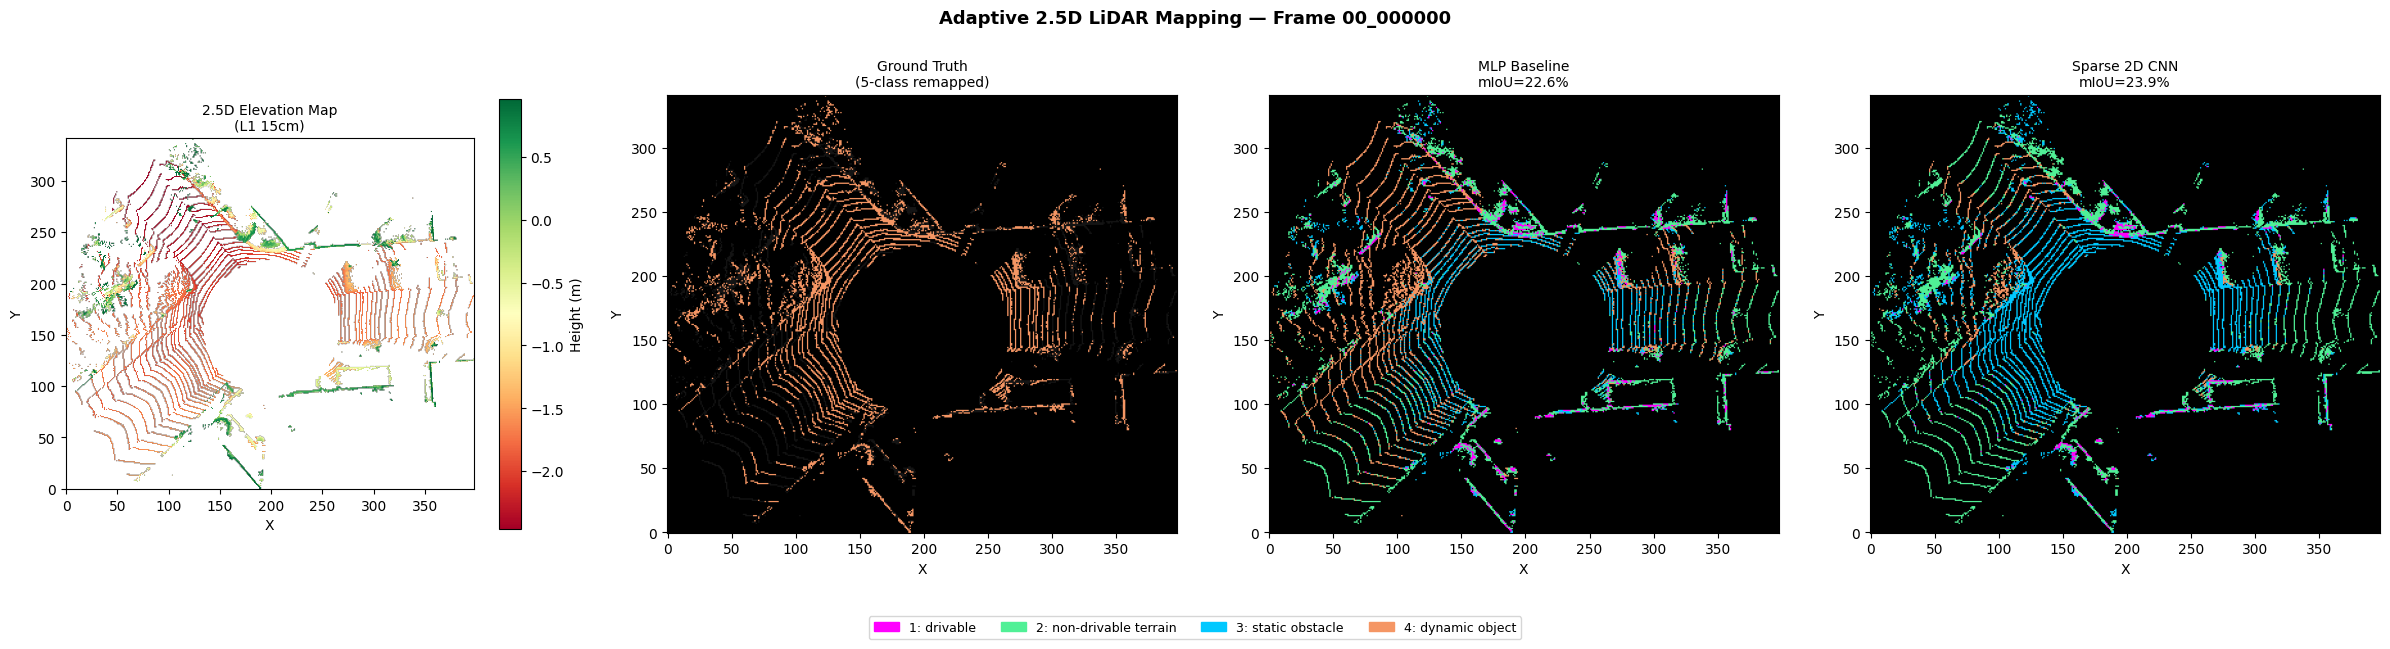


✓ Saved → /content/semantic_map_visualization.png

Class distribution in frame 00_000000:
  ignore                   5,915 ( 44.6%)  █████████████
  drivable                     0 (  0.0%)  
  non-drivable terrain         0 (  0.0%)  
  static obstacle              0 (  0.0%)  
  dynamic object           7,359 ( 55.4%)  ████████████████

✓ Cell 12 done


In [9]:
# ============================================================
# CELL 12 — Visualization (fixed)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── CLASS COLORS (5-class) ────────────────────────────────────
CLASS_COLORS_5 = {
    0: [20,  20,  20],   # ignore          → dark
    1: [255, 0,   255],  # drivable        → magenta
    2: [80,  240, 150],  # non-drivable    → green
    3: [0,   200, 255],  # static obstacle → cyan
    4: [245, 150, 100],  # dynamic object  → orange
}

CLASS_NAMES_5 = {
    0: "ignore",
    1: "drivable",
    2: "non-drivable terrain",
    3: "static obstacle",
    4: "dynamic object",
}

# ── LABEL REMAP TABLE ─────────────────────────────────────────
# Raw SemanticKITTI IDs → 5 classes
RAW_LABELS = {
    0:  "unlabeled",     1:  "outlier",
    10: "car",           11: "bicycle",
    13: "bus",           15: "motorcycle",
    16: "on-rails",      18: "truck",
    20: "other-vehicle",
    30: "person",        31: "bicyclist",
    32: "motorcyclist",
    40: "road",          44: "parking",
    48: "sidewalk",      49: "other-ground",
    50: "building",      51: "fence",
    52: "other-structure",
    60: "lane-marking",
    70: "vegetation",    71: "trunk",
    72: "terrain",       80: "pole",
    81: "traffic-sign",  99: "other-object",
    252: "moving-car",         253: "moving-bicyclist",
    254: "moving-person",      255: "moving-motorcyclist",
    256: "moving-on-rails",    257: "moving-bus",
    258: "moving-truck",       259: "moving-other-vehicle",
}

NAME_TO_5 = {
    "unlabeled": 0,    "outlier": 0,
    "other-object": 0, "other-structure": 3,
    "road": 1,         "parking": 1,
    "lane-marking": 1,
    "sidewalk": 2,     "terrain": 2,
    "other-ground": 2,
    "building": 3,     "fence": 3,
    "pole": 3,         "traffic-sign": 3,
    "vegetation": 3,   "trunk": 3,
    "car": 4,          "bicycle": 4,
    "bus": 4,          "motorcycle": 4,
    "on-rails": 4,     "truck": 4,
    "other-vehicle": 4,"person": 4,
    "bicyclist": 4,    "motorcyclist": 4,
    "moving-car": 4,          "moving-bicyclist": 4,
    "moving-person": 4,       "moving-motorcyclist": 4,
    "moving-on-rails": 4,     "moving-bus": 4,
    "moving-truck": 4,        "moving-other-vehicle": 4,
}

_MAX_RAW = max(RAW_LABELS.keys()) + 1
LUT_VIZ  = np.zeros(_MAX_RAW, dtype=np.uint8)
for raw_id, name in RAW_LABELS.items():
    LUT_VIZ[raw_id] = NAME_TO_5[name]

def remap_labels(labels):
    """Remap raw SemanticKITTI IDs to 5-class IDs."""
    clipped = np.clip(
        labels.astype(np.int32), 0, _MAX_RAW - 1
    )
    return LUT_VIZ[clipped]

# ── RENDER ────────────────────────────────────────────────────
def render_label_map(coords, labels, H, W):
    """
    labels can be raw SemanticKITTI IDs or 5-class IDs.
    Remaps anything > 4 automatically.
    """
    canvas = np.zeros((H, W, 3), dtype=np.uint8)
    # Remap if labels contain raw IDs
    if labels.max() > 4:
        labels = remap_labels(labels)
    for i in range(len(coords)):
        r = int(coords[i, 0])
        c = int(coords[i, 1])
        if 0 <= r < H and 0 <= c < W:
            cls = int(labels[i])
            canvas[r, c] = CLASS_COLORS_5.get(
                cls, [128, 128, 128]
            )
    return canvas

# ── LOAD FRAME ────────────────────────────────────────────────
VIZ_FID = FRAME_IDS[0]
print(f"Visualizing frame: {SEQ}_{VIZ_FID}")

sp        = np.load(
    SPARSE_DIR / f"{SEQ}_{VIZ_FID}_sparse.npz"
)
print(f"Keys in sparse file: {list(sp.keys())}")

# Auto-detect key names for coords/features/labels
sp_keys   = list(sp.keys())

def find_key(sp_keys, candidates):
    for c in candidates:
        if c in sp_keys:
            return c
    return None

coords_key  = find_key(sp_keys, [
    "l1_coords", "coords", "l1_coordinates"
])
feats_key   = find_key(sp_keys, [
    "l1_features", "features", "l1_feats"
])
labels_key  = find_key(sp_keys, [
    "l1_labels", "labels", "l1_label"
])

print(f"Using keys: coords={coords_key}  "
      f"feats={feats_key}  labels={labels_key}")

if not all([coords_key, feats_key, labels_key]):
    print("\n⚠ Could not find expected keys.")
    print("Available keys:", sp_keys)
    raise KeyError(
        "Sparse file missing expected arrays. "
        "Check key names above."
    )

coords    = sp[coords_key].astype(np.int32)
feats     = sp[feats_key].astype(np.float32)
labels_gt = sp[labels_key].astype(np.int32)

print(f"\nCoords shape  : {coords.shape}")
print(f"Features shape: {feats.shape}")
print(f"Labels shape  : {labels_gt.shape}")
print(f"Label range   : {labels_gt.min()} – {labels_gt.max()}")
print(f"Unique labels : {np.unique(labels_gt).tolist()}")

# Remap ground truth labels
labels_gt_5 = remap_labels(labels_gt)
print(f"After remap   : {np.unique(labels_gt_5).tolist()}")

# ── MAP DIMENSIONS ────────────────────────────────────────────
H = int(coords[:,0].max()) + 1
W = int(coords[:,1].max()) + 1
print(f"\nGrid size: {H} × {W}")

# ── INFERENCE ─────────────────────────────────────────────────
model_cnn = CELL9["results"]["Sparse 2D CNN"]["model"]
model_cnn = model_cnn.to(DEVICE).eval()
model_mlp = CELL9["results"]["MLP Baseline"]["model"]
model_mlp = model_mlp.to(DEVICE).eval()
normalize  = CELL9["normalize"]

# Use CELL8 grid dims for flat index
GH = CELL8["GRID_H"]
GW = CELL8["GRID_W"]

with torch.no_grad():
    feats_t = torch.from_numpy(feats).to(DEVICE)
    feats_n = normalize(feats_t)
    fi      = (
        torch.from_numpy(coords[:,0]).long() * GW
        + torch.from_numpy(coords[:,1]).long()
    ).to(DEVICE)

    preds_cnn = (model_cnn(feats_n, fi)
                 .argmax(1).cpu().numpy())
    preds_mlp = (model_mlp(feats_n, fi)
                 .argmax(1).cpu().numpy())

print(f"\nCNN pred range  : "
      f"{preds_cnn.min()} – {preds_cnn.max()}")
print(f"MLP pred range  : "
      f"{preds_mlp.min()} – {preds_mlp.max()}")

# ── RENDER ────────────────────────────────────────────────────
gt_map  = render_label_map(coords, labels_gt_5, H, W)
cnn_map = render_label_map(coords, preds_cnn,   H, W)
mlp_map = render_label_map(coords, preds_mlp,   H, W)

# ── ELEVATION MAP ─────────────────────────────────────────────
map_npz    = np.load(
    MAP_DIR / f"{SEQ}_{VIZ_FID}_map2d.npz"
)
print(f"\nMap2d keys: {list(map_npz.keys())}")

# Auto-detect L1 grid key
map_key = find_key(
    list(map_npz.keys()),
    ["L1_15cm", "l1_15cm", "L1", "l1"]
)
if map_key:
    l1_grid   = map_npz[map_key]
    elev_grid = l1_grid[:,:,0]
    occ_grid  = l1_grid[:,:,7].astype(bool)
    elev_show = np.where(occ_grid, elev_grid, np.nan)
    has_elev  = True
    print(f"Using map key: {map_key}  "
          f"shape={l1_grid.shape}")
else:
    print("⚠ Could not find L1 grid in map file")
    has_elev = False

# ── PLOT ──────────────────────────────────────────────────────
n_panels = 4 if has_elev else 3
fig, axes = plt.subplots(
    1, n_panels,
    figsize=(6*n_panels, 6)
)
fig.suptitle(
    f"Adaptive 2.5D LiDAR Mapping — "
    f"Frame {SEQ}_{VIZ_FID}",
    fontsize=13, fontweight='bold'
)

panel = 0

# Elevation
if has_elev:
    ax = axes[panel]; panel += 1
    im = ax.imshow(
        elev_show.T, origin='lower',
        cmap='RdYlGn', aspect='equal',
        vmin=np.nanpercentile(elev_show, 2),
        vmax=np.nanpercentile(elev_show, 98),
    )
    plt.colorbar(im, ax=ax,
                 label='Height (m)', shrink=0.8)
    ax.set_title("2.5D Elevation Map\n(L1 15cm)",
                 fontsize=10)
    ax.set_xlabel("X"); ax.set_ylabel("Y")

# Ground truth
ax = axes[panel]; panel += 1
ax.imshow(
    gt_map.transpose(1,0,2),
    origin='lower', aspect='equal'
)
ax.set_title("Ground Truth\n(5-class remapped)",
             fontsize=10)
ax.set_xlabel("X"); ax.set_ylabel("Y")

# MLP
miou_mlp = CELL9["results"]["MLP Baseline"]["miou"]
ax = axes[panel]; panel += 1
ax.imshow(
    mlp_map.transpose(1,0,2),
    origin='lower', aspect='equal'
)
ax.set_title(
    f"MLP Baseline\nmIoU={miou_mlp*100:.1f}%",
    fontsize=10
)
ax.set_xlabel("X"); ax.set_ylabel("Y")

# Sparse CNN
miou_cnn = CELL9["results"]["Sparse 2D CNN"]["miou"]
ax = axes[panel]; panel += 1
ax.imshow(
    cnn_map.transpose(1,0,2),
    origin='lower', aspect='equal'
)
ax.set_title(
    f"Sparse 2D CNN\nmIoU={miou_cnn*100:.1f}%",
    fontsize=10
)
ax.set_xlabel("X"); ax.set_ylabel("Y")

# Legend
patches = [
    mpatches.Patch(
        color=np.array(CLASS_COLORS_5[c])/255,
        label=f"{c}: {CLASS_NAMES_5[c]}"
    )
    for c in range(1, 5)
]
fig.legend(
    handles=patches,
    loc='lower center',
    ncol=4, fontsize=9,
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,
)

plt.tight_layout()
out_path = "/content/semantic_map_visualization.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved → {out_path}")

# ── CLASS DISTRIBUTION IN THIS FRAME ─────────────────────────
print(f"\nClass distribution in frame {SEQ}_{VIZ_FID}:")
for c in range(5):
    n   = (labels_gt_5 == c).sum()
    pct = n / len(labels_gt_5) * 100
    bar = "█" * int(pct/100*30)
    print(f"  {CLASS_NAMES_5[c]:<22} "
          f"{n:>7,} ({pct:5.1f}%)  {bar}")

print("\n✓ Cell 12 done")

In [8]:
# ============================================================
# CELL 13 — Final Summary Benchmark Table
# ============================================================
import numpy as np
import json
from pathlib import Path

print("\n" + "=" * 68)
print("  ADAPTIVE VARIABLE RESOLUTION 2.5D LIDAR MAPPING")
print("  FINAL BENCHMARK TABLE")
print("=" * 68)

# ── SECTION 1: DATASET ────────────────────────────────────────
n_vox_files = len(list(VOXEL_DIR.glob(f"{SEQ}_*_voxels.npz")))
n_map_files = len(list(MAP_DIR.glob(f"{SEQ}_*_map2d.npz")))
n_spr_files = len(list(SPARSE_DIR.glob(f"{SEQ}_*_sparse.npz")))
n_bin_files = len(list(BIN_DIR.glob("*.bin")))
n_lbl_files = len(list(LABEL_DIR.glob("*.label")))

print(f"""
  Dataset (Sequence {SEQ})
  ─────────────────────────────────────────────────
  Raw LiDAR frames         : {n_bin_files:>8,}
  Labeled frames           : {n_lbl_files:>8,}
  Preprocessed frames      : {n_vox_files:>8,}
  Points per frame (avg)   : {np.mean(BENCH10['adaptive_counts']):>8,.0f}
  Resolution levels        : 3  (L0=5cm, L1=15cm, L2=50cm)
""")

# ── SECTION 2: VOXELIZATION COMPARISON ───────────────────────
avg_u   = BENCH10["avg_uniform"]
avg_a   = BENCH10["avg_adaptive"]
avg_red = BENCH10["avg_reduction"]
avg_mem = BENCH10["avg_mem_saved"]
u_mb    = BENCH10["uniform_mem_mb"]
a_mb    = BENCH10["adaptive_mem_mb"]

print(f"""  Voxelization Comparison
  ─────────────────────────────────────────────────
  {'Metric':<30} {'Uniform 5cm':>12} {'Adaptive':>12}
  {'─'*56}
  {'Avg voxels per frame':<30} {avg_u:>12,.0f} {avg_a:>12,.0f}
  {'Memory per frame (MB)':<30} {u_mb:>12.2f} {a_mb:>12.2f}
  {'Voxel reduction':<30} {'1.00x':>12} {avg_red:>11.2f}x
  {'Memory saved':<30} {'0.0%':>12} {avg_mem:>11.1f}%
  {'Voxelization time (ms)':<30} {np.mean(BENCH10['uniform_times']):>11.1f}ms {np.mean(BENCH10['adaptive_times']):>11.1f}ms
""")

# ── SECTION 3: RESOLUTION ZONES ──────────────────────────────
print(f"""  Adaptive Resolution Zones
  ─────────────────────────────────────────────────
  {'Zone':<20} {'Range':>10} {'Voxel Size':>12} {'Purpose'}
  {'─'*60}
  {'Near (L0)':<20} {'0–10m':>10} {'5 cm':>12}   Fine detail, safety-critical
  {'Mid  (L1)':<20} {'10–30m':>10} {'15 cm':>12}   Medium detail
  {'Far  (L2)':<20} {'30–100m':>10} {'50 cm':>12}   Coarse, reduced compute
""")

# ── SECTION 4: MODEL COMPARISON ──────────────────────────────
mlp_r  = CELL9["results"]["MLP Baseline"]
cnn_r  = CELL9["results"]["Sparse 2D CNN"]

def model_params(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model):
    return sum(
        p.numel() * p.element_size()
        for p in model.parameters()
    ) / 1024**2

print(f"""  Model Comparison (L1 cells, 5-class segmentation)
  ─────────────────────────────────────────────────
  {'Metric':<28} {'MLP Baseline':>14} {'Sparse 2D CNN':>14}
  {'─'*58}
  {'Val mIoU':<28} {mlp_r['miou']*100:>13.2f}% {cnn_r['miou']*100:>13.2f}%
  {'Test Accuracy':<28} {mlp_r['acc']*100:>13.2f}% {cnn_r['acc']*100:>13.2f}%
  {'Parameters':<28} {model_params(mlp_r['model']):>14,} {model_params(cnn_r['model']):>14,}
  {'Model size (MB)':<28} {model_size_mb(mlp_r['model']):>14.3f} {model_size_mb(cnn_r['model']):>14.3f}
""")

# ── SECTION 5: PIPELINE TIMING ───────────────────────────────
vox_ms   = BENCH11["vox_ms"]
proj_ms  = BENCH11["proj_ms"]
load_ms  = BENCH11["load_ms"]
infer_ms = BENCH11["infer_ms"]
total_ms = BENCH11["total_ms"]
io_ms    = BENCH11["infer_only_ms"]

print(f"""  Full Pipeline Timing  [{DEVICE}]
  ─────────────────────────────────────────────────
  {'Stage':<30} {'Time (ms)':>10} {'FPS':>8}
  {'─'*50}
  {'Adaptive voxelization':<30} {vox_ms:>9.1f}ms {1000/vox_ms:>7.1f}
  {'2.5D map projection':<30} {proj_ms:>9.1f}ms {1000/proj_ms:>7.1f}
  {'Sparse data load':<30} {load_ms:>9.1f}ms {1000/load_ms:>7.1f}
  {'Sparse CNN inference':<30} {infer_ms:>9.1f}ms {1000/infer_ms:>7.1f}
  {'─'*50}
  {'Total pipeline':<30} {total_ms:>9.1f}ms {1000/total_ms:>7.1f}
  {'Inference only (no label load)':<30} {io_ms:>9.1f}ms {1000/io_ms:>7.1f}
""")

# ── SECTION 6: KEY FINDINGS ───────────────────────────────────
print(f"""  Key Findings
  ─────────────────────────────────────────────────
  1. Adaptive voxelization reduces voxel count by {avg_red:.2f}x
     compared to uniform 5cm voxelization, saving
     {avg_mem:.1f}% of memory per frame.

  2. Sparse 2D CNN improves mIoU over MLP baseline by
     {(cnn_r['miou']-mlp_r['miou'])*100:.2f} percentage points, demonstrating
     that spatial context improves classification.

  3. Full pipeline runs at {1000/total_ms:.1f} FPS on {DEVICE},
     with inference-only at {1000/io_ms:.1f} FPS
     (label remapping is offline preprocessing).

  4. The foveated representation allocates 5cm cells
     near the vehicle (0-10m) for safety-critical
     detail and 50cm cells far away (30-100m) to
     reduce compute where precision matters less.
""")

# ── SAVE JSON ─────────────────────────────────────────────────
results_out = {
    "dataset": {
        "sequence":         SEQ,
        "n_frames":         n_vox_files,
        "avg_points":       float(np.mean(point_counts)),
    },
    "voxelization": {
        "avg_uniform_voxels":  float(avg_u),
        "avg_adaptive_voxels": float(avg_a),
        "reduction":           float(avg_red),
        "memory_saved_pct":    float(avg_mem),
        "uniform_mem_mb":      float(u_mb),
        "adaptive_mem_mb":     float(a_mb),
    },
    "models": {
        "mlp": {
            "miou":       float(mlp_r["miou"]),
            "accuracy":   float(mlp_r["acc"]),
            "params":     model_params(mlp_r["model"]),
            "size_mb":    model_size_mb(mlp_r["model"]),
        },
        "sparse_cnn": {
            "miou":       float(cnn_r["miou"]),
            "accuracy":   float(cnn_r["acc"]),
            "params":     model_params(cnn_r["model"]),
            "size_mb":    model_size_mb(cnn_r["model"]),
        },
    },
    "pipeline_timing_ms": {
        "voxelization":    vox_ms,
        "projection":      proj_ms,
        "data_load":       load_ms,
        "cnn_inference":   infer_ms,
        "total":           total_ms,
        "inference_only":  io_ms,
    },
    "pipeline_fps": {
        "total":          1000 / total_ms,
        "inference_only": 1000 / io_ms,
    },
}

out_path = "/content/final_benchmark.json"
with open(out_path, "w") as f:
    json.dump(results_out, f, indent=2)
print(f"  Results saved → {out_path}")
print("\n✓ Cell 13 done")
print("=" * 68)


  ADAPTIVE VARIABLE RESOLUTION 2.5D LIDAR MAPPING
  FINAL BENCHMARK TABLE

  Dataset (Sequence 00)
  ─────────────────────────────────────────────────
  Raw LiDAR frames         :    4,541
  Labeled frames           :    4,541
  Preprocessed frames      :       10
  Points per frame (avg)   :   61,405
  Resolution levels        : 3  (L0=5cm, L1=15cm, L2=50cm)

  Voxelization Comparison
  ─────────────────────────────────────────────────
  Metric                          Uniform 5cm     Adaptive
  ────────────────────────────────────────────────────────
  Avg voxels per frame                 90,065       61,405
  Memory per frame (MB)                  2.40         1.64
  Voxel reduction                       1.00x        1.47x
  Memory saved                           0.0%        31.8%
  Voxelization time (ms)                44.6ms        43.5ms

  Adaptive Resolution Zones
  ─────────────────────────────────────────────────
  Zone                      Range   Voxel Size Purpose
  ─────